In [2]:
!pip install pillow

Defaulting to user installation because normal site-packages is not writeable


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.cm as cm
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

**The governing equation is:**
$$D \frac{d^4w}{dx^4} + N \frac{d^2w}{dx^2} + k w = q(x)$$
**where**
$$k = \Delta\rho \cdot g$$

**First, we initialize our x axis**

In [19]:
L = 100000.0
nx = 5000
dx = L / (nx - 1)
x = np.linspace(0.1, L, nx)

**Now, we add a load vector $q(x)$, in this case a 100,000 Pa load in the center of the model space**

In [23]:
q = np.zeros_like(x)
q[(x>49500) & (x<51500)] = 100000

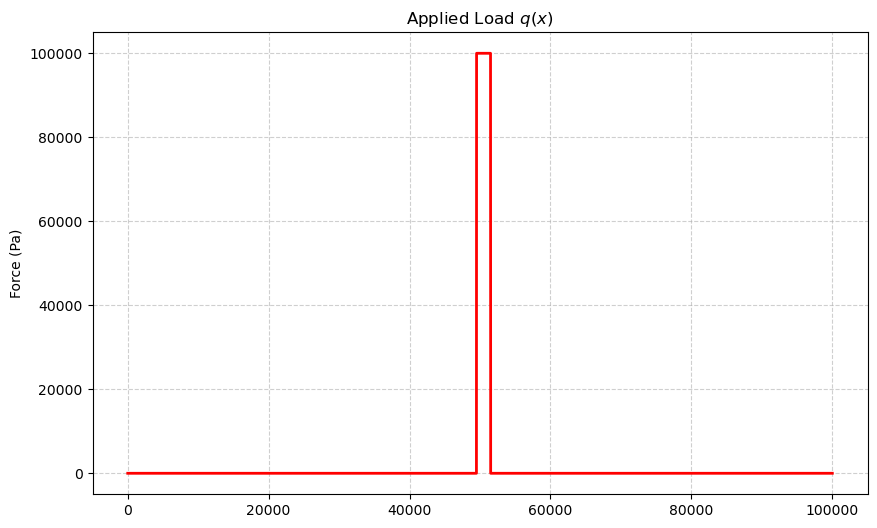

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x, q, color='red', lw=2)
ax.set_title('Applied Load $q(x)$')
ax.set_ylabel('Force (Pa)')
ax.grid(True, linestyle='--', alpha=0.6)

**We then, given $q(x)$, solve for $w(x)$ using a pentadiagonal matrix**

In [65]:
D = 1e20         
N = 0                 # in-plane horizontal force, we will ignore for now  
delta_rho = 3300 
g = 9.81         
k = delta_rho * g 

dx2 = dx**2
dx4 = dx**4

# pentadiagonal matrix solution
c0 = (6 * D / dx4) - (2 * N / dx2) + k   
c1 = (-4 * D / dx4) + (N / dx2)          
c2 = (1 * D / dx4)                             

d0 = np.full(nx, c0)
d1 = np.full(nx - 1, c1)
d2 = np.full(nx - 2, c2)

A = diags([d2, d1, d0, d1, d2], [-2, -1, 0, 1, 2], format='csr')

# boundary condition "pins" edges
for i in [0, 1, nx-2, nx-1]:
    A.data[A.indptr[i]:A.indptr[i+1]] = 0 
    A[i, i] = 1.0                         
    q[i] = 0.0                            

# solve for w
w = spsolve(A, q)

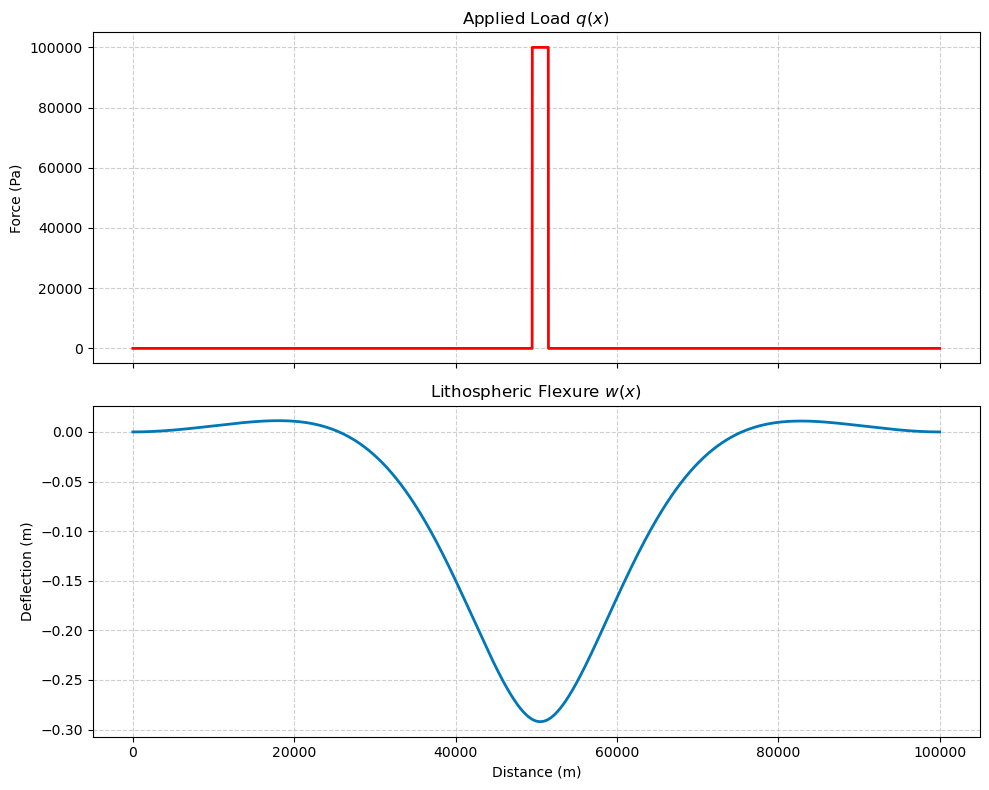

In [66]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(x, q, color='red', lw=2)
ax1.set_title('Applied Load $q(x)$')
ax1.set_ylabel('Force (Pa)')
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(x, -w, color='#0077b6', lw=2)
ax2.set_title('Lithospheric Flexure $w(x)$')
ax2.set_xlabel('Distance (m)')
ax2.set_ylabel('Deflection (m)')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Now, we visualize lithospheric flexure for a range of different values for $D$**

In [43]:
w_list = []

for i in range(1,50):
    D = 10 ** (i/2) # fix this      
    N_force = 0.0    
    delta_rho = 3300 
    g = 9.81         
    k = delta_rho * g 

    dx2 = dx**2
    dx4 = dx**4

    # pentadiagonal matrix solution
    c0 = (6 * D / dx4) - (2 * N_force / dx2) + k   
    c1 = (-4 * D / dx4) + (N_force / dx2)          
    c2 = (1 * D / dx4)                             

    d0 = np.full(nx, c0)
    d1 = np.full(nx - 1, c1)
    d2 = np.full(nx - 2, c2)

    A = diags([d2, d1, d0, d1, d2], [-2, -1, 0, 1, 2], format='csr')

    # boundary condition "pins" edges
    for i in [0, 1, nx-2, nx-1]:
        A.data[A.indptr[i]:A.indptr[i+1]] = 0 
        A[i, i] = 1.0                         
        q[i] = 0.0                            

    # solve for w
    w = spsolve(A, q)
    w_list.append(w)

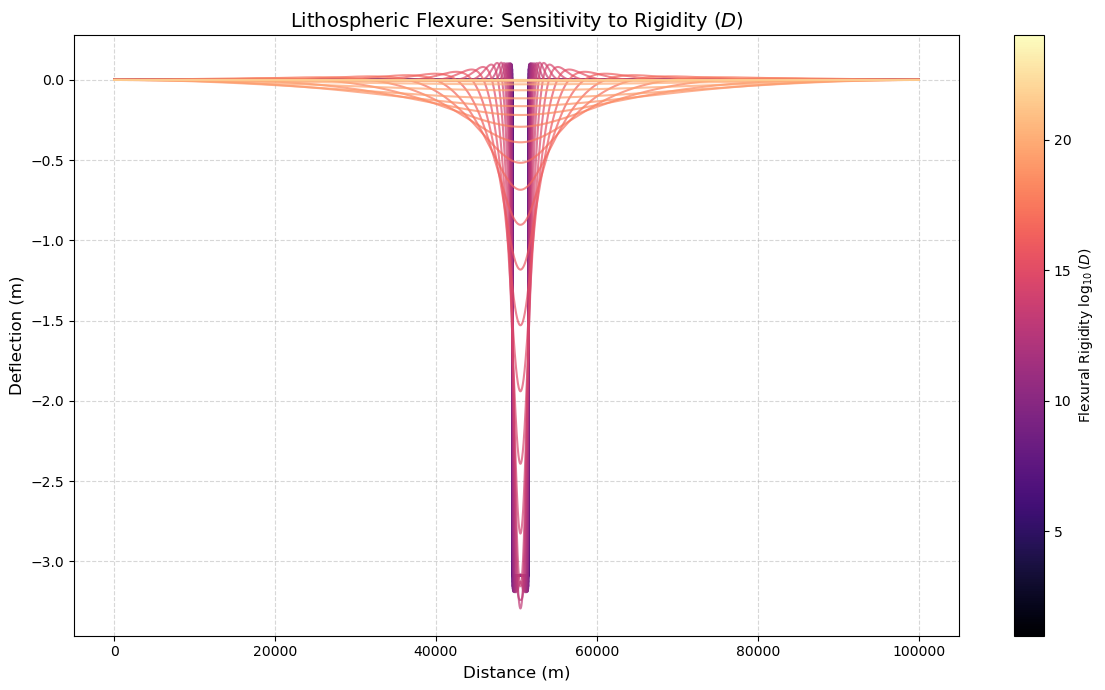

In [44]:
plt.figure(figsize=(12, 7))

colors = cm.magma(np.linspace(0, 0.9, len(w_list)))

for i, w in enumerate(w_list):
    log_D = i + 1    
    plt.plot(x, -w, color=colors[i], alpha=0.7) 

plt.title('Lithospheric Flexure: Sensitivity to Rigidity ($D$)', fontsize=14)
plt.xlabel('Distance (m)', fontsize=12)
plt.ylabel('Deflection (m)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

sm = plt.cm.ScalarMappable(cmap=cm.magma, norm=plt.Normalize(vmin=1, vmax=24))
sm._A = [] 

cbar = plt.colorbar(sm, ax=plt.gca()) 
cbar.set_label('Flexural Rigidity $\log_{10}(D)$')

plt.tight_layout()
plt.show()